## Notebook 10 - Player-level bivariate analysis: centrality by position and outcome
Núria Pascual Salas

**Content:** Bivariate exploration of how player centrality (PageRank) varies by
position and match outcome across the league: whether a position's PageRank differs
between wins and losses, and whether that difference is consistent across positions or
appears only in some. This is the descriptive foundation before the multivariate logistic model at player level.

**Inputs:** player_match_matrix.csv (from notebook 06).

**Outputs:**
- outputs/csv/bivariate_position_outcome.csv
- outputs/figures/pagerank_by_position_outcome.png
- outputs/figures/pagerank_distributions_by_position.png
- outputs/figures/top3_concentration_by_position.png

**Used in:** Chapter 5, Section 5.3 (player-level analysis).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

FIGURES_DIR = 'outputs/figures'
CSV_DIR     = 'outputs/csv'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)

### 1. Load and prepare data

In [ ]:
df = pd.read_csv(f'{CSV_DIR}/player_match_matrix.csv', encoding='utf-8-sig')

# Filter out UNK positions (only 3 cases)
df = df[df['position'] != 'UNK'].copy()

# Filter out players with very few minutes (< 15 min)
n_before = len(df)
df = df[df['minutes_played'] >= 15].copy()
n_after = len(df)

print(f"Rows before minutes filter (< 15 min): {n_before}")
print(f"Rows after filter: {n_after}")
print(f"Removed: {n_before - n_after} ({(n_before-n_after)/n_before*100:.1f}%)")
print()
print("Final position distribution:")
print(df['position'].value_counts())

Rows before minutes filter (< 15 min): 11787
Rows after filter: 11128
Removed: 659 (5.6%)

Final position distribution:
position
MID    4436
DEF    3781
FWD    2139
GK      772
Name: count, dtype: int64


### 2. Summary statistics: PageRank by position × outcome

In [3]:
summary = df.groupby(['position', 'outcome'])['pagerank_pct'].agg(
    ['count', 'mean', 'std', 'median']
).round(3)
print(summary)

# Also save to CSV
summary.to_csv(f'{CSV_DIR}/bivariate_position_outcome.csv')

                  count   mean    std  median
position outcome                             
DEF      draw      1021  7.643  2.756   7.710
         loss      1374  7.716  2.796   7.930
         win       1386  7.456  2.959   7.695
FWD      draw       605  5.452  2.752   4.940
         loss       766  5.119  2.624   4.515
         win        768  5.356  2.718   4.870
GK       draw       216  4.141  1.520   3.890
         loss       281  4.076  1.377   3.870
         win        275  4.065  1.439   3.820
MID      draw      1273  7.122  3.332   6.890
         loss      1640  6.809  3.213   6.355
         win       1523  7.332  3.445   7.200


### 3. Statistical tests: differences within each position

For each position (GK, DEF, MID, FWD), test whether the PageRank distribution
differs significantly across outcomes (W vs D vs L).

In [4]:
test_results = []

for position in ['GK', 'DEF', 'MID', 'FWD']:
    df_pos = df[df['position'] == position]
    wins   = df_pos[df_pos['outcome'] == 'win']['pagerank_pct'].values
    draws  = df_pos[df_pos['outcome'] == 'draw']['pagerank_pct'].values
    losses = df_pos[df_pos['outcome'] == 'loss']['pagerank_pct'].values
    
    if len(wins) == 0 or len(draws) == 0 or len(losses) == 0:
        continue
    
    # Kruskal-Wallis 3-group
    h_stat, p_kw = stats.kruskal(wins, draws, losses)
    
    # Mann-Whitney W vs L
    u_stat, p_mw = stats.mannwhitneyu(wins, losses, alternative='two-sided')
    
    test_results.append({
        'position':      position,
        'n_wins':        len(wins),
        'n_draws':       len(draws),
        'n_losses':      len(losses),
        'mean_pr_win':   round(wins.mean(), 2),
        'mean_pr_draw':  round(draws.mean(), 2),
        'mean_pr_loss':  round(losses.mean(), 2),
        'kw_p':          round(p_kw, 4),
        'mw_p_w_vs_l':   round(p_mw, 4),
    })

df_tests = pd.DataFrame(test_results)
print(df_tests.to_string(index=False))

position  n_wins  n_draws  n_losses  mean_pr_win  mean_pr_draw  mean_pr_loss   kw_p  mw_p_w_vs_l
      GK     275      216       281         4.07          4.14          4.08 0.9260       0.9218
     DEF    1386     1021      1374         7.46          7.64          7.72 0.0894       0.0283
     MID    1523     1273      1640         7.33          7.12          6.81 0.0001       0.0000
     FWD     768      605       766         5.36          5.45          5.12 0.0586       0.0978


### 4. Visualisation 1: Boxplot of PageRank by position × outcome

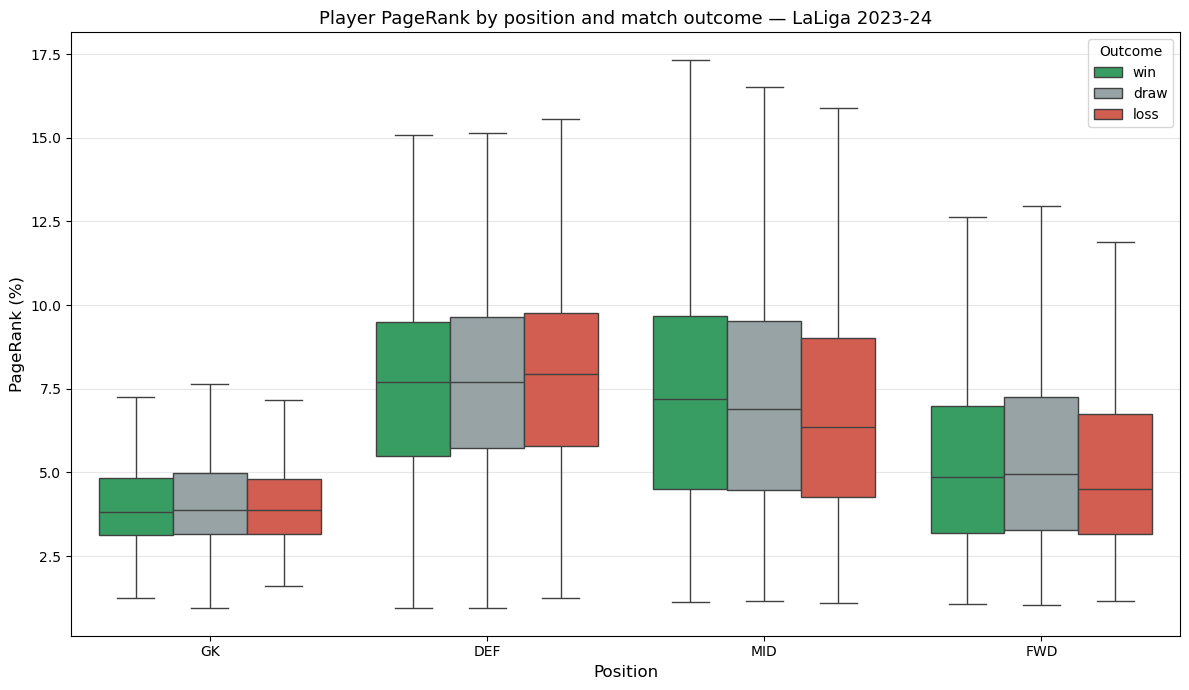

In [5]:
fig, ax = plt.subplots(figsize=(12, 7))

outcome_order = ['win', 'draw', 'loss']
position_order = ['GK', 'DEF', 'MID', 'FWD']
outcome_colors = {'win': '#27ae60', 'draw': '#95a5a6', 'loss': '#e74c3c'}

sns.boxplot(data=df, x='position', y='pagerank_pct', hue='outcome',
            order=position_order, hue_order=outcome_order,
            palette=outcome_colors, showfliers=False, ax=ax)

ax.set_xlabel('Position', fontsize=12)
ax.set_ylabel('PageRank (%)', fontsize=12)
ax.set_title('Player PageRank by position and match outcome — LaLiga 2023-24',
             fontsize=13)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Outcome', loc='upper right')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/pagerank_by_position_outcome.png',
            dpi=130, bbox_inches='tight')
plt.show()

### 5. Visualisation 2: Distributions (KDE) by position

Density plots help see whether the distributions just shift or change shape.

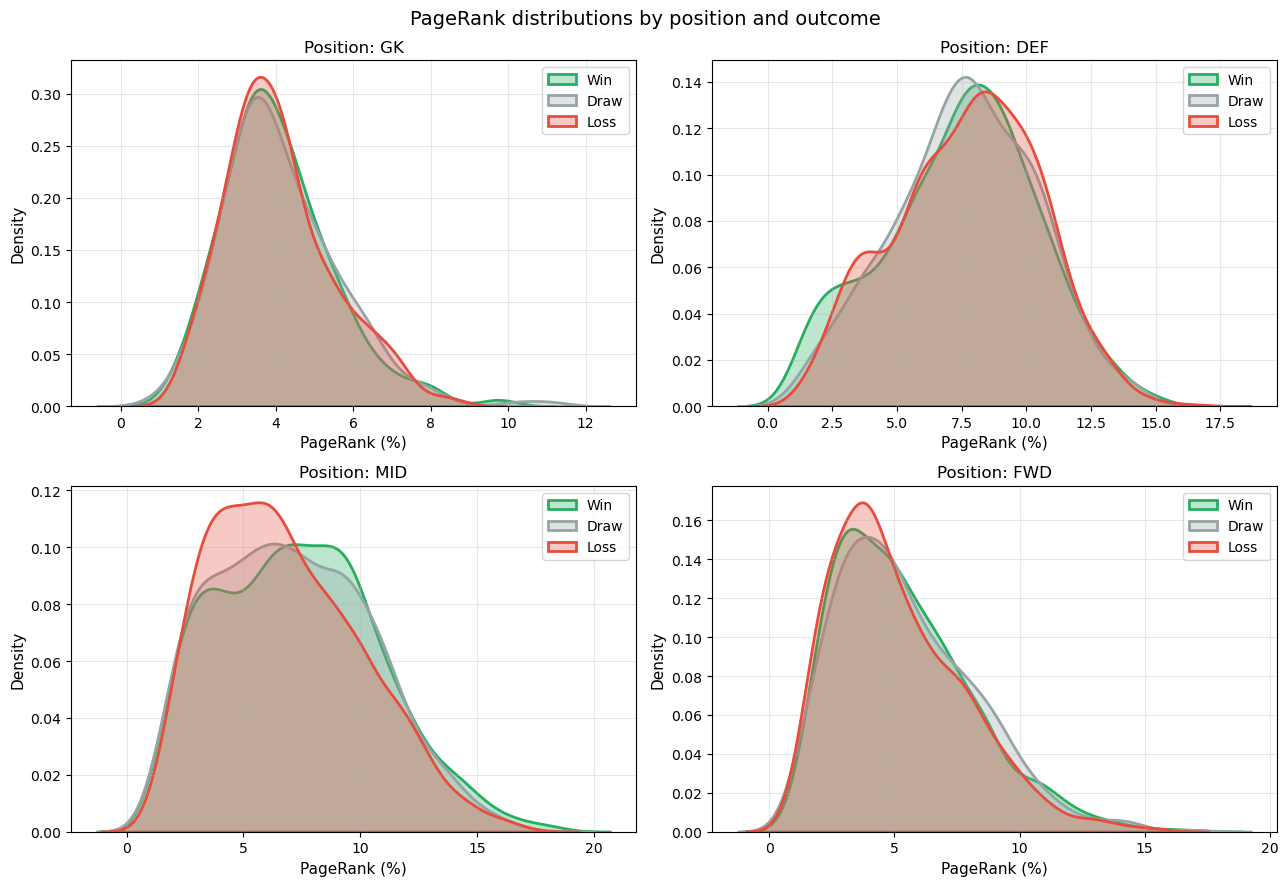

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, position in zip(axes, ['GK', 'DEF', 'MID', 'FWD']):
    df_pos = df[df['position'] == position]
    
    for outcome in outcome_order:
        data = df_pos[df_pos['outcome'] == outcome]['pagerank_pct']
        if len(data) > 1:
            sns.kdeplot(data, ax=ax, label=outcome.capitalize(),
                        color=outcome_colors[outcome], fill=True, alpha=0.3,
                        linewidth=2)
    
    ax.set_xlabel('PageRank (%)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'Position: {position}', fontsize=12)
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle('PageRank distributions by position and outcome', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/pagerank_distributions_by_position.png',
            dpi=130, bbox_inches='tight')
plt.show()

### 6. Top-3 concentration by position


In [7]:
# For each (match_id, team_id, position), get the top-3 sum
top3_per_position = []

for (m_id, t_id, pos), group in df.groupby(['match_id', 'team_id', 'position']):
    if len(group) < 1:
        continue
    top_n = min(3, len(group))
    top_sum = group.nlargest(top_n, 'pagerank_pct')['pagerank_pct'].sum()
    outcome = group['outcome'].iloc[0]
    
    top3_per_position.append({
        'match_id': m_id,
        'team_id':  t_id,
        'position': pos,
        'top3_sum': top_sum,
        'outcome':  outcome,
        'n_players_in_position': len(group),
    })

df_top3 = pd.DataFrame(top3_per_position)
print("Mean top-3 sum by position × outcome:")
print(df_top3.groupby(['position', 'outcome'])['top3_sum'].agg(
    ['mean', 'std', 'count']).round(2))

Mean top-3 sum by position × outcome:
                   mean   std  count
position outcome                    
DEF      draw     27.33  3.81    214
         loss     28.19  3.58    273
         win      27.67  3.72    273
FWD      draw     14.92  4.97    214
         loss     13.81  4.79    273
         win      14.57  4.93    273
GK       draw      4.18  1.49    214
         loss      4.20  1.38    273
         win       4.10  1.43    273
MID      draw     29.10  3.70    214
         loss     27.83  3.77    273
         win      29.32  3.66    273


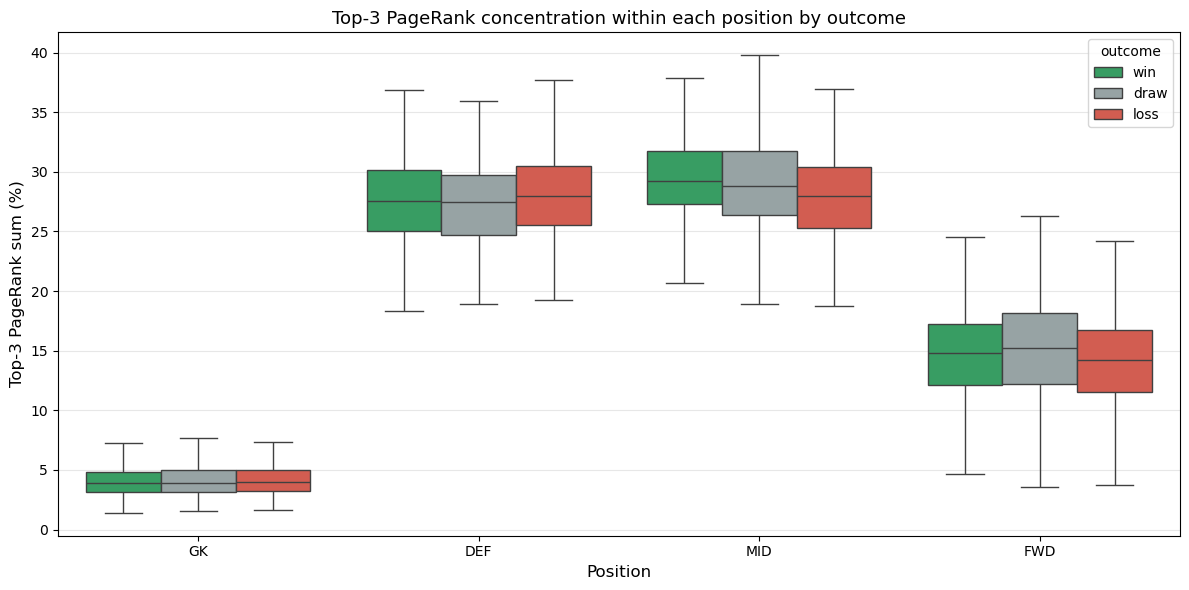

In [8]:
# Visualize top-3 concentration
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(data=df_top3, x='position', y='top3_sum', hue='outcome',
            order=position_order, hue_order=outcome_order,
            palette=outcome_colors, showfliers=False, ax=ax)

ax.set_xlabel('Position', fontsize=12)
ax.set_ylabel('Top-3 PageRank sum (%)', fontsize=12)
ax.set_title('Top-3 PageRank concentration within each position by outcome',
             fontsize=13)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/top3_concentration_by_position.png',
            dpi=130, bbox_inches='tight')
plt.show()

### 7. Effect size: Cohen's d (W vs L) per position

In [9]:
def cohens_d(group1, group2):
    """Compute Cohen's d for two independent samples."""
    n1, n2 = len(group1), len(group2)
    s1, s2 = np.std(group1, ddof=1), np.std(group2, ddof=1)
    pooled_std = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std


print("Cohen's d (W vs L) per position:")
print(f"  Small effect: |d| ~ 0.2 | Medium: |d| ~ 0.5 | Large: |d| ~ 0.8")
print()

for position in ['GK', 'DEF', 'MID', 'FWD']:
    df_pos = df[df['position'] == position]
    wins   = df_pos[df_pos['outcome'] == 'win']['pagerank_pct'].values
    losses = df_pos[df_pos['outcome'] == 'loss']['pagerank_pct'].values
    
    if len(wins) > 1 and len(losses) > 1:
        d = cohens_d(wins, losses)
        magnitude = ('negligible' if abs(d) < 0.2 else
                     'small' if abs(d) < 0.5 else
                     'medium' if abs(d) < 0.8 else 'large')
        print(f"  {position}: d = {d:+.3f}  ({magnitude})")

Cohen's d (W vs L) per position:
  Small effect: |d| ~ 0.2 | Medium: |d| ~ 0.5 | Large: |d| ~ 0.8

  GK: d = -0.008  (negligible)
  DEF: d = -0.090  (negligible)
  MID: d = +0.157  (negligible)
  FWD: d = +0.089  (negligible)


### Summary

In [11]:
print("=" * 70)
print("SUMMARY — Bivariate analysis: PageRank vs Position × Outcome")
print("=" * 70)
print()
print(f"Sample: {len(df)} player-match observations from {df['team_name'].nunique()} teams")
print()
print("--- Tests of difference (W/D/L within each position) ---")
print(df_tests.to_string(index=False))
print()
print("--- Interpretation ---")
sig_positions = df_tests[df_tests['kw_p'] < 0.05]['position'].tolist()
if len(sig_positions) > 0:
    print(f"Positions with significant differences (Kruskal-Wallis p<0.05): {sig_positions}")
else:
    print("No position shows significant PageRank differences across outcomes.")
print()

SUMMARY — Bivariate analysis: PageRank vs Position × Outcome

Sample: 11128 player-match observations from 20 teams

--- Tests of difference (W/D/L within each position) ---
position  n_wins  n_draws  n_losses  mean_pr_win  mean_pr_draw  mean_pr_loss   kw_p  mw_p_w_vs_l
      GK     275      216       281         4.07          4.14          4.08 0.9260       0.9218
     DEF    1386     1021      1374         7.46          7.64          7.72 0.0894       0.0283
     MID    1523     1273      1640         7.33          7.12          6.81 0.0001       0.0000
     FWD     768      605       766         5.36          5.45          5.12 0.0586       0.0978

--- Interpretation ---
Positions with significant differences (Kruskal-Wallis p<0.05): ['MID']

